# Perform unfolding on EEG data from Stop-signal task with RidgeCV

In [48]:
import pickle
import warnings
import os

import mne
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from himalaya.ridge import RidgeCV

# sys.path.insert(1, '../')
from ridgeCV_model import UnfoldRidgeCVPy
import ridgeCV_model
from models import models

import unfold_model

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

Define picks

In [12]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG data

In [13]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform RidgeCV unfolding

In [14]:
current_unfold_model = models.get_full_model()

In [ ]:
for file_name in file_names[:1]:
    try:
        # read events dict
        with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
            events = pickle.load(handle) # events dict channel_name:events_df
    
        # read EEG
        raw = mne.io.read_raw_brainvision(
            f'{eeg_data_dir}/{file_name}.vhdr',
            preload=True,
            eog=('HEOG', 'VEOG'),
        ).pick(picks=picks)
    
        # perform unfolding separately for each channel
        # channels = raw.info['ch_names']
        channels = ['Fz']
        results_channels = dict()
        for channel in channels:
            channel_events_df = events[channel]
            # clear bad segments
            channel_events_df = channel_events_df[channel_events_df['bad'] == False]
            # get EEG data
            eeg_data = raw.get_data(picks=channel)
            # cast EEG data from V to uV
            eeg_data = eeg_data * 1000000
            
            model = UnfoldRidgeCVPy(
                u_model = current_unfold_model,
                linear_estimator = RidgeCV(alphas=[0.001, 0.01, 0.1, 1])
            )
            model.fit(eeg_data, channel_events_df)
            predicted_raw_train = model.predict(signal=eeg_data, events_df=channel_events_df)

            epochs_indices = ridgeCV_model.get_epochs_indices(channel_events_df)
            eeg_epochs = ridgeCV_model.epochs_from_raw(eeg_data, epochs_indices)

    except Exception as e:
        print(e)

(196, 114)


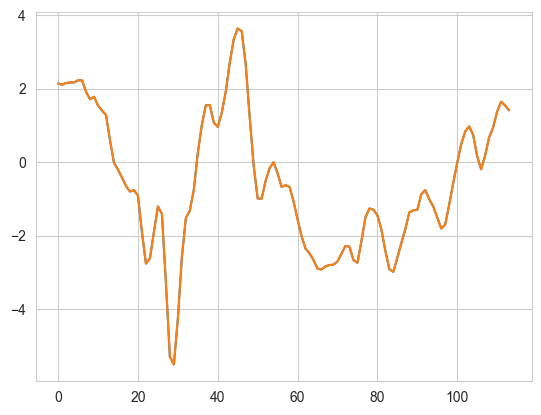

In [52]:
plt.plot(np.mean(eeg_epochs, axis=0), label='original')
plt.plot(np.mean(predicted_raw_train, axis=0), label='predicted')

print(predicted_raw_train.shape)

In [110]:
model.linear_estimator.coef_

array([[ 2.57416313e-11,  3.15180473e-11,  1.22847403e-11, ...,
        -2.87622350e-11, -1.89328352e-11, -2.38849570e-11],
       [ 2.43136584e-12,  1.79140823e-12,  1.01920089e-12, ...,
         4.96579861e-12,  6.97363336e-12,  7.16870014e-12],
       [ 8.27315214e-12,  8.51086774e-12,  4.93323707e-12, ...,
        -1.74861545e-11, -1.93028939e-11, -2.22471979e-11],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [149]:
coefs = model.linear_estimator.coef_.copy()
coefs

array([[ 2.57416313e-11,  3.15180473e-11,  1.22847403e-11, ...,
        -2.87622350e-11, -1.89328352e-11, -2.38849570e-11],
       [ 2.43136584e-12,  1.79140823e-12,  1.01920089e-12, ...,
         4.96579861e-12,  6.97363336e-12,  7.16870014e-12],
       [ 8.27315214e-12,  8.51086774e-12,  4.93323707e-12, ...,
        -1.74861545e-11, -1.93028939e-11, -2.22471979e-11],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [150]:
coefs_reshaped = coefs.reshape(coefs.shape[-1], -1, coefs.shape[-1])
coefs_reshaped[:,:,0]

array([[2.57416313e-11, 2.43136584e-12, 8.27315214e-12, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [137]:
coefs = model.linear_estimator.coef_.copy()

coefs2 = []

for coef_i in range(0,coefs.shape[-1]):
    pat = coefs[:,coef_i]
    part_resh = pat.reshape(114, 353)
    coefs2.append(part_resh)

coefs2 = np.array(coefs2)

In [138]:
coefs2.shape

(114, 114, 353)

In [144]:
coefs2[1,:,:]

array([[3.15180473e-11, 1.79140823e-12, 8.51086774e-12, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

(353,)


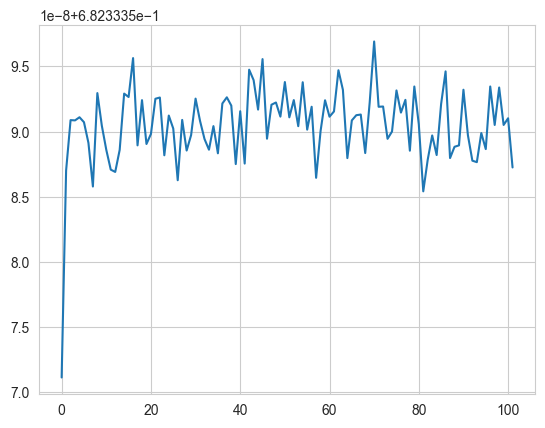

In [146]:
coefs_sum = coefs2.sum(axis=0).sum(axis=0)
print(coefs_sum.shape)

plt.plot(coefs_sum[0:102].flatten())

In [86]:
coefs_sum

array([-1.93698952e-08, -3.49581026e-09,  3.71530264e-10,  3.50493131e-10,
        5.90751595e-10,  2.11797111e-10, -1.37211152e-09, -4.72259765e-09,
        2.44338126e-09, -5.49413207e-11, -1.90725535e-09, -3.42664398e-09,
       -3.60487702e-09, -1.91278302e-09,  2.40399385e-09,  2.14365484e-09,
        5.12851978e-09, -1.56537824e-09,  1.90184398e-09, -1.46041809e-09,
       -6.93166249e-10,  2.00880478e-09,  2.10425248e-09, -2.32665440e-09,
        7.20674812e-10, -2.75903251e-10, -4.23991509e-09,  3.85965925e-10,
       -1.96278657e-09, -7.76989403e-10,  2.01909405e-09,  3.08321844e-10,
       -1.07641847e-09, -1.89758957e-09, -8.88736114e-11, -2.17466120e-09,
        1.64650486e-09,  2.11941881e-09,  1.48399956e-09, -3.00152080e-09,
        1.05241861e-09, -2.96252626e-09,  4.23929323e-09,  3.43874033e-09,
        1.17931289e-09,  5.05114994e-09, -1.05462785e-09,  1.55167496e-09,
        1.72225099e-09,  6.38899324e-10,  3.29075757e-09,  5.83742964e-10,
        1.90804264e-09, -

In [98]:
model_matrix = model.get_model_matrix(eeg_data, channel_events_df)
epochs_indices = ridgeCV_model.get_epochs_indices(channel_events_df)
eeg_epochs = ridgeCV_model.epochs_from_raw(eeg_data, epochs_indices)
model_matrix_epochs = ridgeCV_model.epochs_from_model_matrix(model_matrix, epochs_indices)

targets = eeg_epochs  # shape of (n_samples, n_targets) -> n_epochs, epoch_len
X = model_matrix_epochs.reshape(eeg_epochs.shape[0], -1)  # shape of (n_samples, n_targets * n_predictors)

/Users/anuszka/Projects/neuroNoodle/unfold/unfold_model.py:604: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sri'] = df['sri'].fillna(0)
/Users/anuszka/Projects/neuroNoodle/unfold/unfold_model.py:605: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ssd'] = df['ssd'].fillna(0)


In [118]:
model_matrix_epochs.shape

(196, 114, 353)

In [103]:
print(model_matrix_epochs.shape)
X.shape

(196, 114, 353)


(196, 40242)

In [108]:
a = X.copy().T.reshape(196, 114, 353)
a

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [109]:
(model_matrix_epochs == a).all()

False

In [83]:
coeftable = model.coeftable

In [87]:
coeftable  = model.coeftable.copy(deep=True)
coeftable['estimate'] = coefs_sum
coeftable

,channel,coefname,estimate,eventname,group,stderror,time
0,1,baseline,-1.936990e-08,baseline,None,None,0.000000
1,1,baseline,-3.495810e-09,baseline,None,None,0.015625
2,1,baseline,3.715303e-10,baseline,None,None,0.031250
3,1,baseline,3.504931e-10,baseline,None,None,0.046875
4,1,baseline,5.907516e-10,baseline,None,None,0.062500
...,...,...,...,...,...,...,...
348,1,(Intercept),0.000000e+00,response_nostop,None,None,0.531250
349,1,(Intercept),0.000000e+00,response_nostop,None,None,0.546875
350,1,(Intercept),0.000000e+00,response_nostop,None,None,0.562500
351,1,(Intercept),0.000000e+00,response_nostop,None,None,0.578125


(102,)


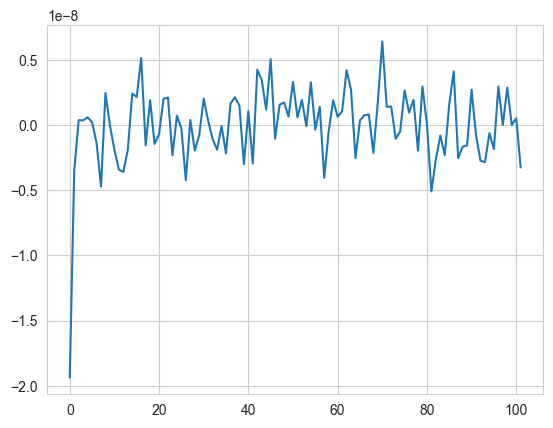

In [89]:
baseline_data = coeftable[coeftable['eventname'] == 'baseline']['estimate'].to_numpy()
plt.plot(baseline_data.flatten())
print(baseline_data.flatten().shape)

In [41]:
model.linear_estimator.coef_.shape
coefs = model.linear_estimator.coef_
coefs_reshaped = model.linear_estimator.coef_.reshape(coefs.shape[-1], -1, coefs.shape[-1])
coefs_reshaped.shape

(114, 353, 114)

In [42]:
model.coeftable

,channel,coefname,estimate,eventname,group,stderror,time
0,1,baseline,0.976757,baseline,None,None,0.000000
1,1,baseline,0.968095,baseline,None,None,0.015625
2,1,baseline,0.942067,baseline,None,None,0.031250
3,1,baseline,0.922031,baseline,None,None,0.046875
4,1,baseline,0.917117,baseline,None,None,0.062500
...,...,...,...,...,...,...,...
348,1,(Intercept),-0.281629,response_nostop,None,None,0.531250
349,1,(Intercept),0.081020,response_nostop,None,None,0.546875
350,1,(Intercept),0.400354,response_nostop,None,None,0.562500
351,1,(Intercept),0.179445,response_nostop,None,None,0.578125


In [43]:
coeftable  = model.coeftable.copy(deep=True)
display(coeftable)

coefs_reshaped_stacked = np.mean(coefs_reshaped, axis=0).mean(axis=-1)

coeftable['estimate'] = coefs_reshaped_stacked

,channel,coefname,estimate,eventname,group,stderror,time
0,1,baseline,0.976757,baseline,None,None,0.000000
1,1,baseline,0.968095,baseline,None,None,0.015625
2,1,baseline,0.942067,baseline,None,None,0.031250
3,1,baseline,0.922031,baseline,None,None,0.046875
4,1,baseline,0.917117,baseline,None,None,0.062500
...,...,...,...,...,...,...,...
348,1,(Intercept),-0.281629,response_nostop,None,None,0.531250
349,1,(Intercept),0.081020,response_nostop,None,None,0.546875
350,1,(Intercept),0.400354,response_nostop,None,None,0.562500
351,1,(Intercept),0.179445,response_nostop,None,None,0.578125


In [44]:
coeftable

,channel,coefname,estimate,eventname,group,stderror,time
0,1,baseline,0.000050,baseline,None,None,0.000000
1,1,baseline,0.000050,baseline,None,None,0.015625
2,1,baseline,0.000050,baseline,None,None,0.031250
3,1,baseline,0.000050,baseline,None,None,0.046875
4,1,baseline,0.000050,baseline,None,None,0.062500
...,...,...,...,...,...,...,...
348,1,(Intercept),0.000916,response_nostop,None,None,0.531250
349,1,(Intercept),0.000916,response_nostop,None,None,0.546875
350,1,(Intercept),0.000916,response_nostop,None,None,0.562500
351,1,(Intercept),0.000916,response_nostop,None,None,0.578125


In [13]:
eeg_epochs.shape

(196, 114)

In [14]:
X = model_matrix_epochs.reshape(eeg_epochs.shape[0], -1)
X.shape

(196, 40242)

In [16]:
a = np.dot(X, coefs)
a.shape

(196, 114)

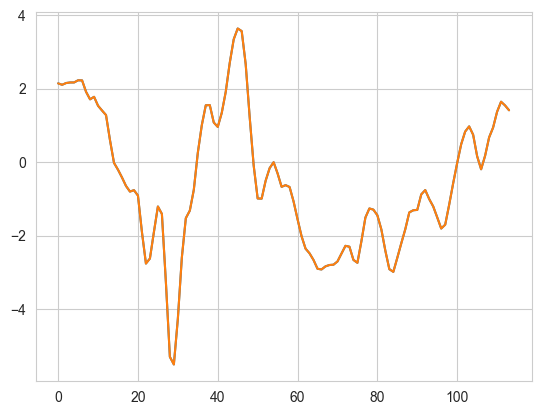

In [17]:
plt.plot(np.mean(a, axis=0))

plt.plot(np.mean(eeg_epochs, axis=0))

In [92]:
betas_n = np.array(betas)

In [2]:
betas_n.shape

NameError: name 'betas_n' is not defined

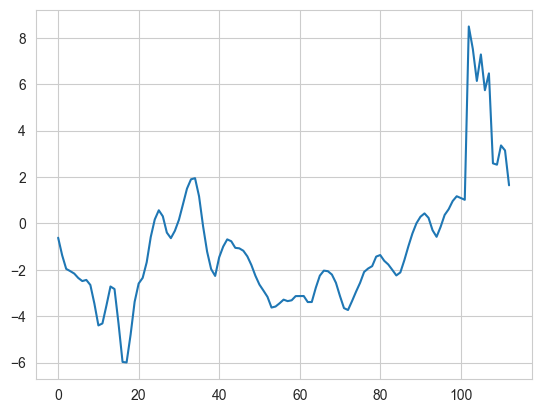

In [104]:
d = np.sum(betas_n, axis=0)

plt.plot(d[115:114*2])

In [33]:
alphas = np.array(alphas)
alphas

array([[1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
       [1. ],
      

In [56]:
ridge_coefs_res_s = np.sum(ridge_coefs_res,axis=0).sum(axis=-1)
ridge_coefs_res_s

array([ 6.56372057e-01,  6.56372056e-01,  6.56372057e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372057e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372057e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372056e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372056e-01,  6.56372057e-01,
        6.56372057e-01,  6.56372057e-01,  6.56372057e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372057e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372057e-01,  6.56372056e-01,  6.56372056e-01,
        6.56372057e-01,  6.56372056e-01,  6.56372057e-01,  6.56372056e-01,
        6.56372056e-01,  6.56372057e-01,  6.56372056e-01,  6.56372057e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372057e-01,  6.56372057e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372056e-01,  6.56372057e-01,
        6.56372056e-01,  6.56372056e-01,  6.56372056e-01,  6.56372056e-01,
        6.56372057e-01,  

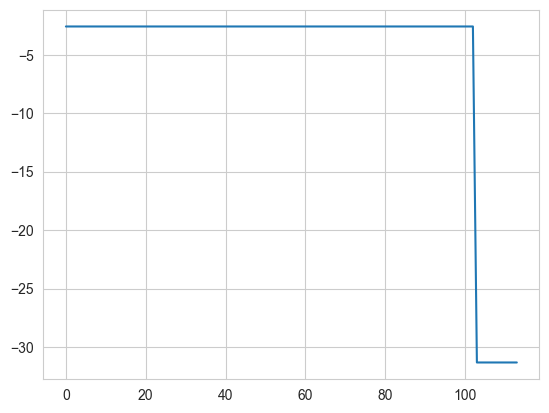

In [58]:
plt.plot(ridge_coefs_res_s[114:114+114])

In [12]:
ridge_coefs = clf.coef_

In [67]:
ridge_coefs[:,0]

array([-1.12443026e-11, -2.58983816e-12, -8.36179843e-13, ...,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [60]:
ridge_coefs_res = ridge_coefs.reshape(114, -1 ,114)
ridge_coefs_res.shape

(114, 353, 114)

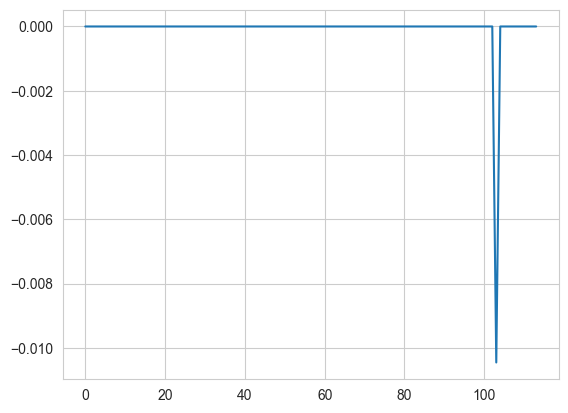

In [75]:
plt.plot(ridge_coefs_res[0,0:114,50].flatten())

In [63]:
eeg_data.shape

(1, 22770)

In [64]:
eeg_epochs.shape

(197, 114)

In [65]:
model_matrix_epochs.shape

(197, 114, 353)

In [33]:
channel_events_df

,index,latency,duration,id,event,event_general,type,ssd,response_type,stop_type,sri,baseline,bad,ssd_center,ssd_standardized,ssd_normalized,sri_center,sri_standardized,sri_normalized
4,4,128,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,baseline,100.0,n-a,SE,0.0,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
5,4,128,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,0.0,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
6,6,134,0,47,Stimulus/ 3-STOP1-SE-L,stop/1/SE,stop,100.0,n-a,SE,0.0,-45.443583,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
7,7,150,0,33,Stimulus/ 3-R-B-STOP1-SE-L,response/incorrect/1,response_stop,100.0,incorrect,n-a,250.0,-45.443583,False,-15.671642,3.05946,-0.479468,99.095395,4.54492,1.801523
8,8,243,0,3,Stimulus/ 3-B-STOP1-SE-L,go/stop/1/SE,go,100.0,n-a,SE,0.0,21.692167,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,626,22553,0,5,Stimulus/ 3-B-STOP1-SS-L,go/stop/1/SS,go,100.0,n-a,SS,0.0,-5.885500,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
628,628,22559,0,49,Stimulus/ 3-STOP1-SS-L,stop/1/SS,stop,100.0,n-a,SS,0.0,-5.885500,False,-15.671642,3.05946,-0.479468,NaN,NaN,NaN
629,629,22668,0,1,Stimulus/ 3-B-NOSTOP-L,go/nostop,go,0.0,n-a,n-a,0.0,-21.871833,False,NaN,NaN,NaN,NaN,NaN,NaN
630,629,22668,0,1,Stimulus/ 3-B-NOSTOP-L,go/nostop,baseline,0.0,n-a,n-a,0.0,-21.871833,False,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
mm_list = []

for start, end in indices:
    if start >= 0 and end <= model_m.shape[0]:
        # Extract the epoch with consistent shape
        mm_e = model_m[start:end, :]
        mm_list.append(np.array(mm_e))
    else:
        # Skip this index if it would result in an out-of-bounds slice
        continue

mm_list = np.stack(mm_list)

In [37]:
model_m.shape

(22769, 353)

In [53]:
mm_list.shape

(197, 114, 353)